### IMPORTS

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import Sequential, Input, layers, optimizers
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.applications.vgg16 import VGG16
from keras.applications.resnet50 import ResNet50
from keras.applications.efficientnet import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
# from PIL import Image

### CONFIGURATION

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
RANDOM_SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

### PATHS

In [3]:
ORIGINAL_DIR = "../raw_data/Original"
AUGMENTED_DIR = "../raw_data/Augmented"

### LOAD DATASETS FROM DIRECTORY

In [4]:
## Train dataset - Augmented data

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    AUGMENTED_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["Non-Stone", "Stone"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_SEED
)

Found 35457 files belonging to 2 classes.


2026-03-12 11:55:01.647703: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-03-12 11:55:01.647864: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-03-12 11:55:01.647878: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-03-12 11:55:01.647949: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-12 11:55:01.648425: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
## Full Original Dataset

full_original = tf.keras.preprocessing.image_dataset_from_directory(
    ORIGINAL_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["Non-Stone", "Stone"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=RANDOM_SEED
)

Found 3364 files belonging to 2 classes.


In [6]:
full_original_shuffled = full_original.shuffle(
    buffer_size=len(full_original) * BATCH_SIZE,
    seed=RANDOM_SEED,
    reshuffle_each_iteration=False
)

### SPLIT ORIGINAL DATASET

In [7]:
## Val and Test dataset - From Full Original dataset

total_batches = len(full_original)
val_batches = total_batches // 2

val_dataset = full_original_shuffled.take(val_batches).cache().prefetch(AUTOTUNE)
test_dataset = full_original_shuffled.skip(val_batches).cache().prefetch(AUTOTUNE)

### LABEL DISTRIBUTION

In [8]:
true_val_labels = np.concatenate([y.numpy() for _, y in val_dataset]).flatten().astype(int)

2026-03-12 11:55:17.776384: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### PREPROCESSING LAYERS

In [9]:
vgg_preprocess = tf.keras.applications.vgg16.preprocess_input
resnet_preprocess = tf.keras.applications.resnet50.preprocess_input
efficientnet_preprocess = tf.keras.applications.efficientnet.preprocess_input

In [10]:
def prepare(dataset, preprocess_input):
    return (
        dataset.map(lambda img, label: (preprocess_input(img), label), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    )

In [11]:
def get_datasets(preprocess_input):
    return (
        prepare(train_dataset, preprocess_input),
        prepare(val_dataset, preprocess_input),
        prepare(test_dataset, preprocess_input)
    )

### PLOT HISTORY

In [12]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    # Loss
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    # AUC
    axes[2].plot(history.history['auc'],     label='Train')
    axes[2].plot(history.history['val_auc'], label='Val')
    axes[2].set_title(f'{title} — AUC')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### CLASSIFICATION REPORT

In [13]:
target_names = ["Non-stone", "Stone"]
true_labels = np.concatenate([y.numpy() for _, y in test_dataset]).flatten().astype(int)

2026-03-12 13:34:04.780441: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [14]:
def get_classification_report(model, test_dt):
    pred_probs = model.predict(test_dt, verbose=1)
    pred_labels = (pred_probs > 0.5).astype(int).flatten()
    report = classification_report(true_labels, pred_labels, target_names=target_names)

    return report, pred_labels

### CONFUSION MATRIX

In [15]:
def plot_cm(pred_labels, title):
    cm = confusion_matrix(true_labels, pred_labels)
    cm = pd.DataFrame(cm,
                    index=["True Non-Stone", "True Stone"],
                    columns=["Pred Non-Stone", "Pred Stone"])

    plt.figure(figsize=(7,5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 14})
    plt.title(f"Confusion Matrix - {title}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show

    return cm

### BASELINE MODEL CNN

In [16]:
def build_baseline_model():
    model = Sequential()

    model.add(Input((224, 224, 3)))

    model.add(layers.Rescaling(1./255))

    model.add(layers.Conv2D(16, kernel_size=3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2))

    model.add(layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2))

    model.add(layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2))

    model.add(layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        loss="binary_crossentropy",
        optimizer=optimizers.Adam(learning_rate=1e-4),
        metrics=["accuracy",
                 keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")]
    )

    return model

In [17]:
baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,520,481 (24.87 MB)

 Trainable params: 6,520,481 (24.87 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# CALLBACKS

es_baseline = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=10,
    verbose=1,
    restore_best_weights=True
)

checkpoint_baseline = ModelCheckpoint(
    filepath="../models/baseline_best.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [19]:
# TRAIN

baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[es_baseline, checkpoint_baseline]
)

Epoch 1/30


2026-03-12 13:36:02.996184: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6465 - auc: 0.6936 - loss: 0.6981 - precision: 0.6392 - recall: 0.4918
Epoch 1: val_auc improved from None to 0.93955, saving model to ../models/baseline_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.7073 - auc: 0.7672 - loss: 1.0474 - precision: 0.6991 - recall: 0.6322 - val_accuracy: 0.9062 - val_auc: 0.9395 - val_loss: 0.7459 - val_precision: 0.8827 - val_recall: 0.9255
Epoch 2/30
1107/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7253 - auc: 0.7377 - loss: 29.9151 - precision: 0.6995 - recall: 0.7004
Epoch 2: val_auc did not improve from 0.93955
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 38s 34ms/step - accuracy: 0.7280 - auc: 0.7330 - loss: 109.7416 - precision: 0.7028 - recall: 0.7020 - val_accuracy: 0.9068 - val_auc: 0.9096 - val_loss: 60.8985 - val_precision: 0.8647 - val_recall: 0.9528
Epoch 3/30
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7295 - auc: 0.7272 - loss: 1127.9533 - precision

In [20]:
baseline_results = baseline_model.evaluate(test_dataset, verbose=1, return_dict=True)
print(baseline_results)

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9077 - auc: 0.9310 - loss: 0.8275 - precision: 0.8972 - recall: 0.9041
{'accuracy': 0.9076738357543945, 'auc': 0.9309756755828857, 'loss': 0.8275420069694519, 'precision': 0.897172212600708, 'recall': 0.9041450619697571}


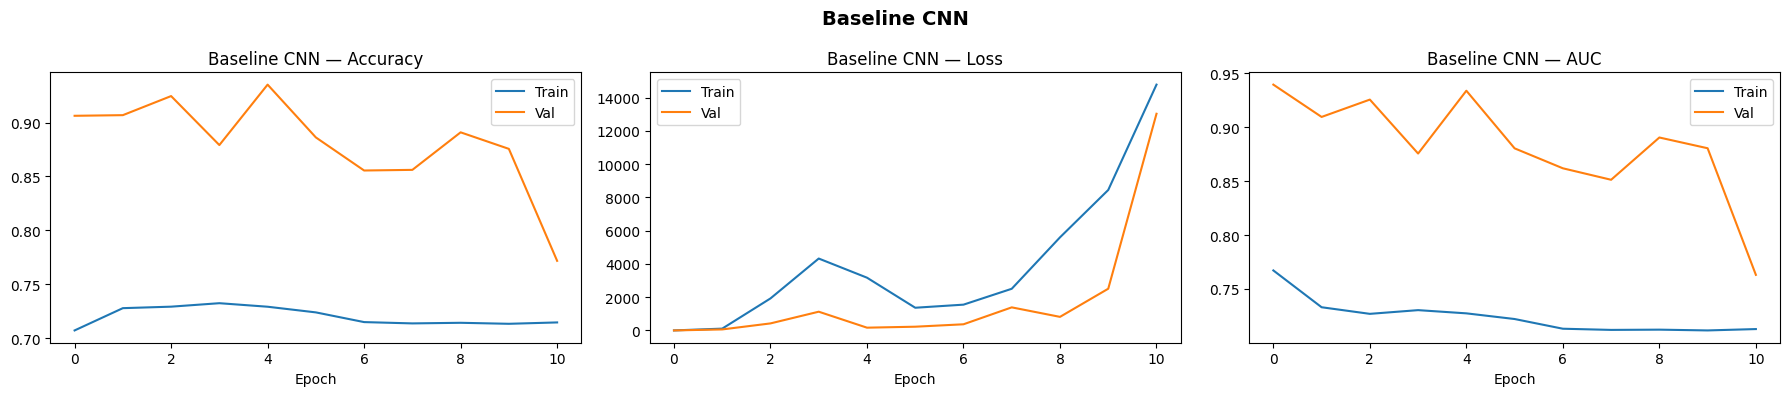

In [21]:
plot_history(baseline_history, "Baseline CNN")

In [22]:
baseline_report, baseline_pred_labels = get_classification_report(baseline_model, test_dataset)
print(baseline_report)

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
              precision    recall  f1-score   support

   Non-stone       0.92      0.91      0.91       896
       Stone       0.90      0.90      0.90       772

    accuracy                           0.91      1668
   macro avg       0.91      0.91      0.91      1668
weighted avg       0.91      0.91      0.91      1668



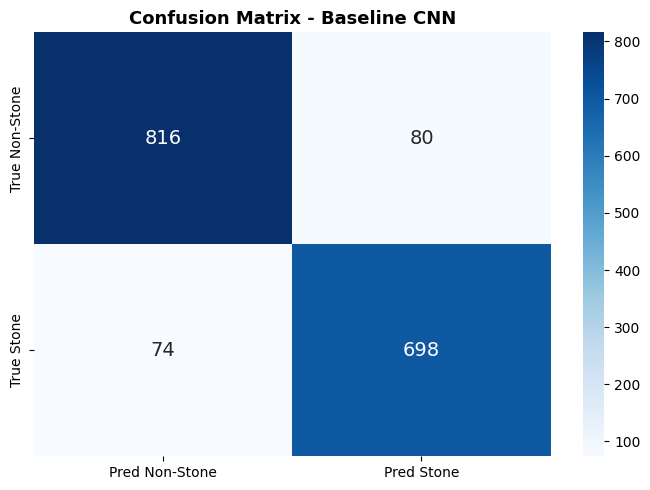

In [23]:
cm_baseline_model = plot_cm(baseline_pred_labels, "Baseline CNN")

### PRETRAINED MODELS

In [24]:
input_shape = IMG_SIZE + (3,)

def load_model(pretrained_model):

    model = pretrained_model(weights="imagenet", include_top=False, input_shape=input_shape)

    return model

In [25]:
def set_nontrainable_layers(model):
    model.trainable = False
    return model

In [26]:
def add_last_layers(model):
    '''Take a pre-trained model, set its parameters as non-trainable, and add additional trainable layers on top'''
    # $CHALLENGIFY_BEGIN
    base_model = set_nontrainable_layers(model)
    pooling_layer = layers.GlobalAveragePooling2D()
    dense_layer = layers.Dense(256, activation='relu')
    prediction_layer = layers.Dense(1, activation='sigmoid')


    model = Sequential([
        base_model,
        pooling_layer,
        dense_layer,
        prediction_layer
    ])
    return model

In [27]:
def build_pretrained_model(pretrained_model):
    model = load_model(pretrained_model)
    model = add_last_layers(model)

    model.compile(
        loss="binary_crossentropy",
        optimizer=optimizers.Adam(learning_rate=1e-4),
        metrics=["accuracy",
                 keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")]
    )
    return model

### VGG16

In [28]:
train_vgg, val_vgg, test_vgg = get_datasets(vgg_preprocess)

In [29]:
vgg_model = build_pretrained_model(VGG16)
vgg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [30]:
# CALLBACKS

es_vgg = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=10,
    verbose=1,
    restore_best_weights=True
)

checkpoint_vgg = ModelCheckpoint(
    filepath="../models/vgg_best.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [31]:
vgg_history = vgg_model.fit(train_vgg,
                            validation_data=val_vgg,
                            epochs=20,
                            callbacks=[es_vgg, checkpoint_vgg])

Epoch 1/20
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.6642 - auc: 0.7088 - loss: 0.8382 - precision: 0.6384 - recall: 0.6345
Epoch 1: val_auc improved from None to 0.93292, saving model to ../models/vgg_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 181s 162ms/step - accuracy: 0.7428 - auc: 0.8091 - loss: 0.5681 - precision: 0.7297 - recall: 0.6952 - val_accuracy: 0.8414 - val_auc: 0.9329 - val_loss: 0.3482 - val_precision: 0.9295 - val_recall: 0.7205
Epoch 2/20
1108/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8247 - auc: 0.9006 - loss: 0.3961 - precision: 0.8297 - recall: 0.7765
Epoch 2: val_auc improved from 0.93292 to 0.95155, saving model to ../models/vgg_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 179s 162ms/step - accuracy: 0.8316 - auc: 0.9059 - loss: 0.3846 - precision: 0.8341 - recall: 0.7886 - val_accuracy: 0.8697 - val_auc: 0.9515 - val_loss: 0.2821 - val_precision: 0.8623 - val_recall: 0.8634
Epoch 3/20
1108/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accur

In [32]:
vgg_results = vgg_model.evaluate(test_vgg, verbose=1, return_dict=True)
print(vgg_results)

53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.9179 - auc: 0.9750 - loss: 0.2060 - precision: 0.9379 - recall: 0.8808
{'accuracy': 0.9178656935691833, 'auc': 0.9750279188156128, 'loss': 0.20599089562892914, 'precision': 0.9379310607910156, 'recall': 0.8808290362358093}


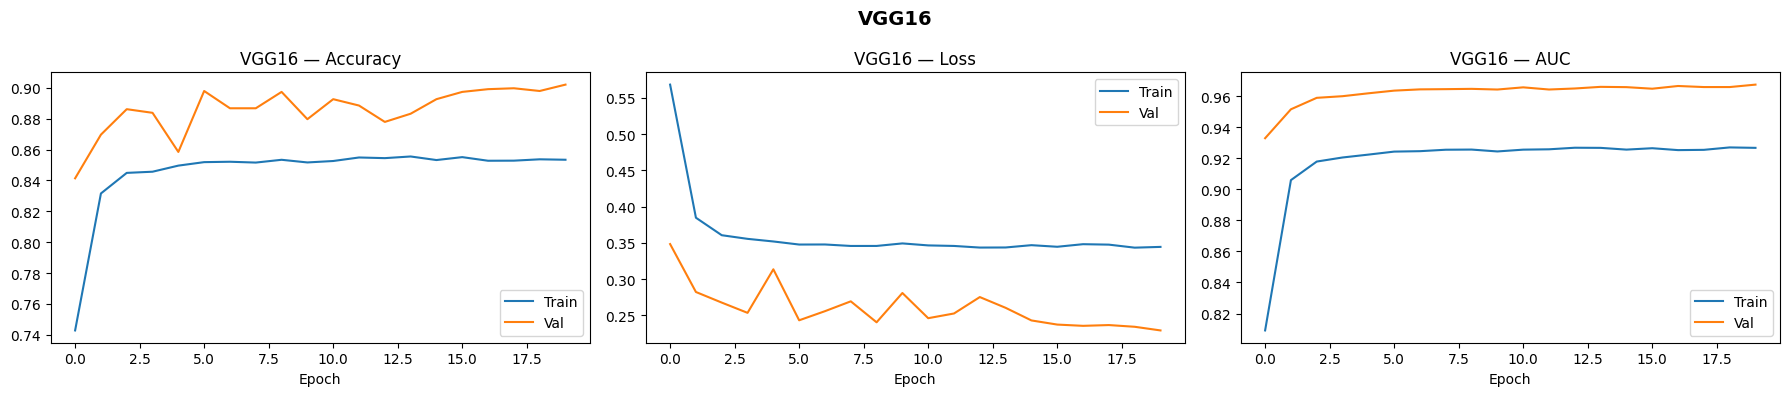

In [33]:
plot_history(vgg_history, "VGG16")

In [34]:
vgg_report, vgg_pred_labels = get_classification_report(vgg_model, test_vgg)
print(vgg_report)

53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step
              precision    recall  f1-score   support

   Non-stone       0.90      0.95      0.93       896
       Stone       0.94      0.88      0.91       772

    accuracy                           0.92      1668
   macro avg       0.92      0.92      0.92      1668
weighted avg       0.92      0.92      0.92      1668



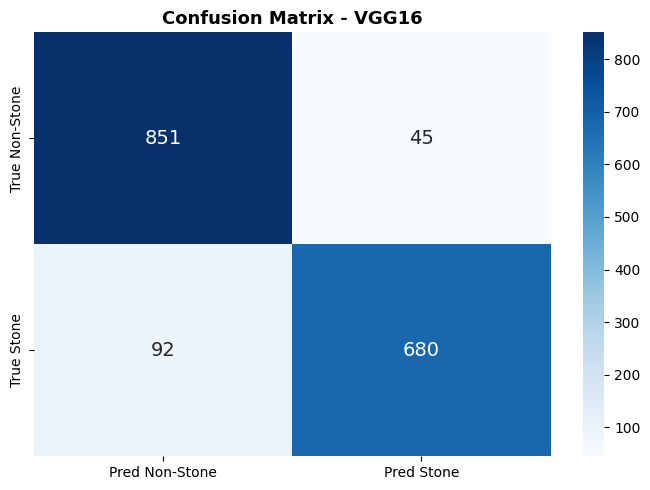

In [35]:
cm_vgg = plot_cm(vgg_pred_labels, "VGG16")

### ResNet50

In [36]:
train_resnet, val_resnet, test_resnet = get_datasets(resnet_preprocess)

In [37]:
resnet_model = build_pretrained_model(ResNet50)
resnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [38]:
# CALLBACKS

es_resnet = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=8,
    verbose=1,
    restore_best_weights=True
)

checkpoint_resnet = ModelCheckpoint(
    filepath="../models/resnet_best.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [39]:
resnet_history = resnet_model.fit(train_resnet,
                            validation_data=val_resnet,
                            epochs=30,
                            callbacks=[es_resnet, checkpoint_resnet])

Epoch 1/30
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7361 - auc: 0.8035 - loss: 0.5255 - precision: 0.7304 - recall: 0.6693
Epoch 1: val_auc improved from None to 0.96230, saving model to ../models/resnet_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 128s 111ms/step - accuracy: 0.7946 - auc: 0.8703 - loss: 0.4471 - precision: 0.7987 - recall: 0.7366 - val_accuracy: 0.8980 - val_auc: 0.9623 - val_loss: 0.2773 - val_precision: 0.9540 - val_recall: 0.8248
Epoch 2/30
1108/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8588 - auc: 0.9276 - loss: 0.3429 - precision: 0.8694 - recall: 0.8133
Epoch 2: val_auc improved from 0.96230 to 0.97829, saving model to ../models/resnet_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 120s 108ms/step - accuracy: 0.8663 - auc: 0.9352 - loss: 0.3256 - precision: 0.8749 - recall: 0.8257 - val_accuracy: 0.9316 - val_auc: 0.9783 - val_loss: 0.2090 - val_precision: 0.9280 - val_recall: 0.9280
Epoch 3/30
1108/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step -

In [40]:
resnet_results = resnet_model.evaluate(test_resnet, verbose=1, return_dict=True)
print(resnet_results)

53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - accuracy: 0.9616 - auc: 0.9936 - loss: 0.1042 - precision: 0.9527 - recall: 0.9650
{'accuracy': 0.9616307020187378, 'auc': 0.9935623407363892, 'loss': 0.10419593751430511, 'precision': 0.9526854157447815, 'recall': 0.9650259017944336}


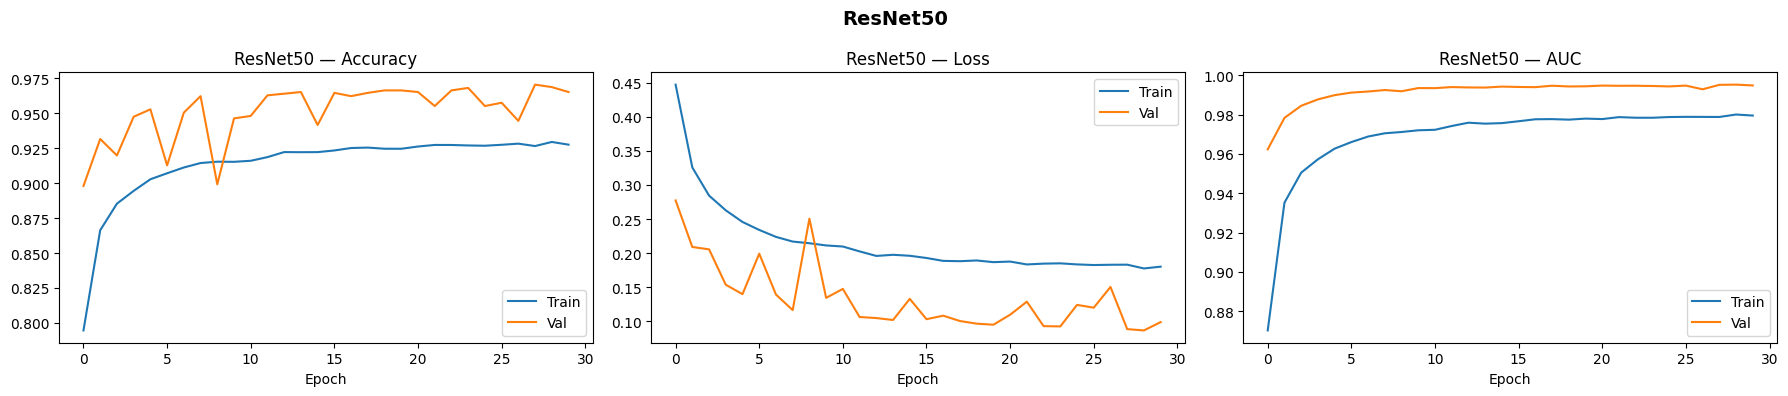

In [41]:
plot_history(resnet_history, "ResNet50")

In [42]:
resnet_report, resnet_pred_labels = get_classification_report(resnet_model, test_resnet)
print(resnet_report)

53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step
              precision    recall  f1-score   support

   Non-stone       0.97      0.96      0.96       896
       Stone       0.95      0.97      0.96       772

    accuracy                           0.96      1668
   macro avg       0.96      0.96      0.96      1668
weighted avg       0.96      0.96      0.96      1668



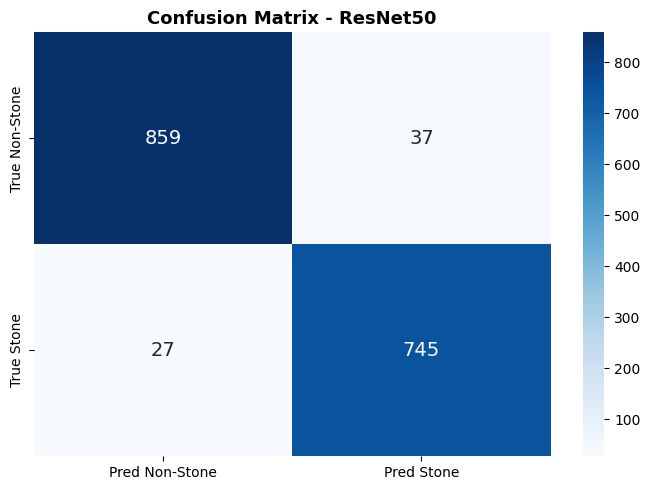

In [43]:
cm_resnet = plot_cm(resnet_pred_labels, "ResNet50")

### EfficientNet

In [44]:
train_efficientnet, val_efficientnet, test_efficientnet = get_datasets(efficientnet_preprocess)

In [45]:
efficientnet_model = build_pretrained_model(EfficientNetB0)
efficientnet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [46]:
# CALLBACKS

es_efficientnet = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=7,
    verbose=1,
    restore_best_weights=True
)

checkpoint_efficientnet = ModelCheckpoint(
    filepath="../models/efficientnet_best.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [47]:
efficientnet_history = efficientnet_model.fit(train_efficientnet,
                            validation_data=val_efficientnet,
                            epochs=25,
                            callbacks=[es_efficientnet, checkpoint_efficientnet])

Epoch 1/25
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7367 - auc: 0.8036 - loss: 0.5349 - precision: 0.7438 - recall: 0.6484
Epoch 1: val_auc improved from None to 0.95044, saving model to ../models/efficientnet_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 95s 80ms/step - accuracy: 0.7822 - auc: 0.8567 - loss: 0.4754 - precision: 0.7932 - recall: 0.7086 - val_accuracy: 0.8455 - val_auc: 0.9504 - val_loss: 0.3390 - val_precision: 0.9458 - val_recall: 0.7155
Epoch 2/25
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8352 - auc: 0.9075 - loss: 0.3909 - precision: 0.8495 - recall: 0.7778
Epoch 2: val_auc improved from 0.95044 to 0.96838, saving model to ../models/efficientnet_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 84s 76ms/step - accuracy: 0.8441 - auc: 0.9159 - loss: 0.3733 - precision: 0.8550 - recall: 0.7939 - val_accuracy: 0.8998 - val_auc: 0.9684 - val_loss: 0.2532 - val_precision: 0.9065 - val_recall: 0.8795
Epoch 3/25
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/s

In [48]:
efficientnet_results = efficientnet_model.evaluate(test_efficientnet, verbose=1, return_dict=True)
print(efficientnet_results)

53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.9592 - auc: 0.9907 - loss: 0.1398 - precision: 0.9513 - recall: 0.9611
{'accuracy': 0.9592326283454895, 'auc': 0.9907331466674805, 'loss': 0.13976092636585236, 'precision': 0.9512820243835449, 'recall': 0.9611399173736572}


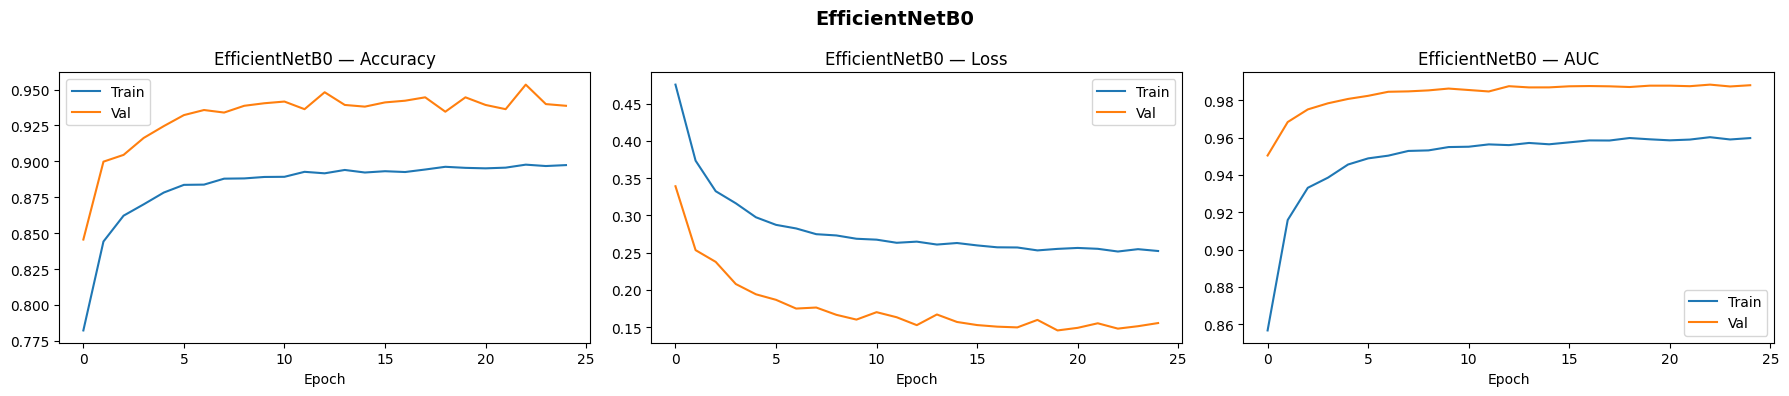

In [49]:
plot_history(efficientnet_history, "EfficientNetB0")

In [50]:
efficientnet_report, efficientnet_pred_labels = get_classification_report(efficientnet_model, test_efficientnet)
print(efficientnet_report)

53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step
              precision    recall  f1-score   support

   Non-stone       0.97      0.96      0.96       896
       Stone       0.95      0.96      0.96       772

    accuracy                           0.96      1668
   macro avg       0.96      0.96      0.96      1668
weighted avg       0.96      0.96      0.96      1668



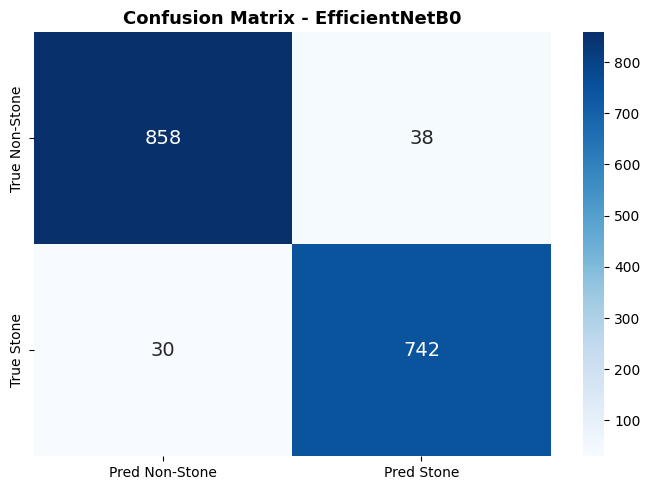

In [51]:
cm_efficientnet = plot_cm(efficientnet_pred_labels, "EfficientNetB0")

### MODEL COMPARISON

In [52]:
results_df = pd.DataFrame({
    "Baseline CNN"  : baseline_results,
    "VGG16"         : vgg_results,
    "ResNet50"      : resnet_results,
    "EfficientNetB0": efficientnet_results,
}).T.round(4)

print(results_df)

                accuracy     auc    loss  precision  recall
Baseline CNN      0.9077  0.9310  0.8275     0.8972  0.9041
VGG16             0.9179  0.9750  0.2060     0.9379  0.8808
ResNet50          0.9616  0.9936  0.1042     0.9527  0.9650
EfficientNetB0    0.9592  0.9907  0.1398     0.9513  0.9611


In [53]:
from google import genai
from PIL import Image
import os
from dotenv import load_dotenv

load_dotenv()

client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

# Grab a sample image from your test set
IDX = 5
BATCH_NUM = 3

for images, labels in test_efficientnet.skip(BATCH_NUM).take(1):
    img_tensor = images[IDX:IDX+1]
    true_label = int(labels[IDX].numpy())

img_pil = Image.fromarray(images[IDX].numpy().astype("uint8"))

# Test vision call
response = client.models.generate_content(
    model="gemini-2.5-flash-lite",
    contents=["What do you see in this image?", img_pil]
)

print(response.text)

/var/folders/lw/rvgrg7c94tg8r69r3wm5l1cw0000gn/T/ipykernel_79239/4210702572.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(labels[IDX].numpy())
2026-03-17 21:19:14.493527: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


The image appears to be an axial CT scan of the abdomen. Here's what I can observe:

**Anatomical Structures Visible:**

*   **Spine:** The vertebral column is clearly visible in the center of the image.
*   **Kidneys:** Both kidneys are present, located on either side of the spine.
*   **Abdominal Wall:** The musculature of the abdominal wall is visible.
*   **Intestines/Bowel:** Portions of the small and large intestines are seen within the abdominal cavity.
*   **Blood Vessels:** The aorta and inferior vena cava, major blood vessels, are likely present near the spine, though their exact delineation might be subtle without contrast enhancement.

**Potential Abnormalities or Findings (requiring medical interpretation):**

*   **Right Kidney:** There appears to be a focal area of increased density within the right kidney, possibly representing a **kidney stone (calculus)** or another type of focal lesion.
*   **Left Kidney:** Similar to the right, there might be a focal area of increas